--- Manual MLR Parameters (Normal Equation) ---
Intercept (b0): 55.3115
Coefficient for Hours Studied (b1): 7.2081
Coefficient for Sleep Hours (b2): 0.8009
Coefficient for Sample Question Papers Practiced (b3): 0.7401

Test Set R-squared Score: 0.1366


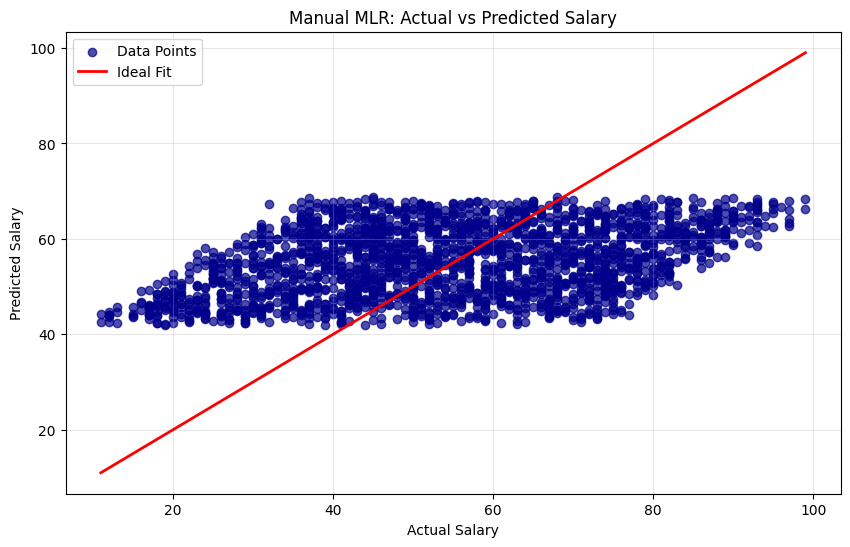

ValueError: X has 2 features, but StandardScaler is expecting 3 features as input.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. LOAD AND PREPARE DATA
# Using a typical salary dataset structure for MLR
# Columns: 'YearsExperience', 'EducationLevel', 'Salary'
df = pd.read_csv('Student_Performance.csv')
df = df.dropna()

# --- CONFIGURATION ---
# Multiple Independent Variables (X1, X2)
FEATURE_COLS = ['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced'] 
TARGET_COL = 'Performance Index'

X = df[FEATURE_COLS].values 
y = df[TARGET_COL].values

# 2. PREPROCESSING (Using Sklearn for Utilities)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Helps avoid matrix inversion issues with large numbers)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. MANUAL MLR LOGIC (The Normal Equation)
# We need to add a column of 1s to X_train to account for the Intercept (b0)
# X_b is the "Design Matrix"
X_b = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled] 

# Apply the Normal Equation: θ = (XᵀX)⁻¹ Xᵀy
# .T is Transpose, .dot() is Matrix Multiplication, np.linalg.inv is Inversion
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)

# Extracting parameters
intercept = theta_best[0]
coefficients = theta_best[1:]

print("--- Manual MLR Parameters (Normal Equation) ---")
print(f"Intercept (b0): {intercept:.4f}")
for i, col in enumerate(FEATURE_COLS):
    print(f"Coefficient for {col} (b{i+1}): {coefficients[i]:.4f}")

# 4. PREDICTIONS & EVALUATION
# Prepare test set with bias column
X_test_b = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]
y_pred = X_test_b.dot(theta_best)

# Calculate R-squared manually: 1 - (SSR / SST)
ssr = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ssr / sst)

print(f"\nTest Set R-squared Score: {r2:.4f}")

# 5. VISUALIZATION (Actual vs Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='darkblue', alpha=0.7, label='Data Points')
# Diagonal line representing perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Ideal Fit')
plt.title('Manual MLR: Actual vs Predicted Salary')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. MANUAL PREDICTION FUNCTION
def predict_manual(features_list):
    """
    Input: [YearsExperience, EducationLevel]
    """
    scaled = scaler.transform([features_list])
    scaled_with_bias = np.insert(scaled, 0, 1) # Add the 1 for intercept
    return scaled_with_bias.dot(theta_best)

# Example usage
example_input = [5.0, 3.0] 
print(f"\nManual Prediction for {example_input}: ${predict_manual(example_input):.2f}")